# 4.2 — Topological Early Warning Indicators for Liquefaction

**Идея.** Циклический отклик грунта живёт в фазовом пространстве **X = (PPR, q, ε)** —
поровое давление, девиатор, осевая деформация. По мере приближения к разжижению гистерезисные
петли разрастаются, а топология траектории меняется. Считаем по этому облаку **устойчивую
гомологию** (H0 — разрастание траектории, H1 — петли) и строим индикатор

**TEWI = total persistence H0 + total persistence H1**.

Гипотеза: топология разжижающегося отклика устойчиво отличается от стабильного, поэтому TEWI
служит **ранним предиктором разжижения**. Данные — сырые массивы циклических опытов
(деления внутри цикла), читаются напрямую из пиклов.

> Если перед разжижением топология резко меняется — появляется новый предиктор, и работа
> превращается в *Topological Early Warning Indicators for Liquefaction* (AI for Science).

## Окружение и доступ к сырым опытам

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import os, glob, pickle
from liquefaction_ai.viz import new_figure, save_figure, QUALITATIVE, INK
from liquefaction_ai.topology import (build_phase_space, topological_early_warning,
                                      compute_persistence, persistence_summary)
LIQ_C, STAB_C = "#c46b6b", "#7FB286"   # пастельные: разжижение / стабильно

# Корень с объектами (как в 1_1_3). Раннее предупреждение считаем на сырых массивах опыта.
ROOT_CANDIDATES = [
    Path("/Users/nikita/Desktop/Новая папка 4/Облако разжижения"),
    REPO_ROOT.parent / "Облако разжижения",            # смонтированный сосед репозитория
    REPO_ROOT.parent.parent / "Облако разжижения",
    REPO_ROOT / "data" / "Облако разжижения",
]
_env = os.environ.get("LIQ_REAL_ROOT", "").strip()
if _env: ROOT_CANDIDATES.insert(0, Path(_env))
CLOUD_ROOT = next((p for p in ROOT_CANDIDATES if p.exists()), ROOT_CANDIDATES[-1])
# сколько опытов брать на каждый класс (для скорости; на своей машине увеличьте)
MAX_PER_CLASS = int(os.environ.get("LIQ_TEWI_MAX", "8"))
print("Корень данных:", CLOUD_ROOT, "| существует:", CLOUD_ROOT.exists())

Корень данных: /Users/nick/Desktop/projects/liquefaction-ai/data/Облако разжижения | существует: False


## Безопасное чтение сырых опытов

Пиклы сериализованы классом `CyclicData` из digitrock; читаем их без зависимостей через
заглушку (как в 1_1_3). Берём массивы `cycles`, `PPR`, `deviator`, `strain` по точкам.

In [2]:
class _Stub:
    def __setstate__(self, state):
        if isinstance(state, dict): self.__dict__.update(state)
class RealUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("numpy") or module in ("builtins","collections","_codecs","copy_reg"):
            return super().find_class(module, name)
        return type(name, (_Stub,), {})
def load_pickle(p):
    with open(p, "rb") as f: return RealUnpickler(f).load()
def gv(o, n, d=None):
    dd = getattr(o, "__dict__", {}); v = dd.get(n, d)
    if hasattr(v, "__dict__"):
        vd = v.__dict__; return vd.get("_value", vd.get("value", v))
    return v

def sample_tests(max_per_class=8):
    """Собрать по несколько разжижившихся и стабильных опытов из доступных объектов."""
    liq, stable = [], []
    obj_dirs = []
    for ttype in ["Потенциал разжижения", "Штормовое разжижение"]:
        td = CLOUD_ROOT / ttype
        if td.is_dir():
            obj_dirs += sorted([p for p in td.iterdir() if p.is_dir()])
    for od in obj_dirs:
        dps = glob.glob(str(od / "**" / "data CyclicModel*"), recursive=True)
        if not dps: continue
        D = load_pickle(dps[0])["data"]
        for k, d in D.items():
            cyc = gv(d, "cycles"); ppr = gv(d, "PPR"); dev = gv(d, "deviator"); eps = gv(d, "strain")
            if any(x is None for x in (cyc, ppr, dev, eps)) or len(cyc) < 60:
                continue
            rec = {"object": od.name, "lab": k, "cycles": np.asarray(cyc, float), "ppr": np.asarray(ppr, float),
                   "q": np.asarray(dev, float), "eps": np.asarray(eps, float), "Nmax": float(np.nanmax(cyc))}
            if np.nanmax(ppr) >= 0.95 and len(liq) < max_per_class: liq.append(rec)
            elif np.nanmax(ppr) < 0.75 and len(stable) < max_per_class: stable.append(rec)
        if len(liq) >= max_per_class and len(stable) >= max_per_class:
            break
    return liq, stable

liq_tests, stable_tests = sample_tests(MAX_PER_CLASS)
print(f"Опытов: разжижение={len(liq_tests)} | стабильные={len(stable_tests)}")
RAW_DATA_AVAILABLE = bool(liq_tests and stable_tests)
if not RAW_DATA_AVAILABLE:
    print(
        "SKIP 4.2: сырые пиклы циклических опытов не найдены "
        f"(liq={len(liq_tests)}, stable={len(stable_tests)}). "
        "Задайте LIQ_REAL_ROOT или положите папку 'Облако разжижения' рядом с репозиторием, "
        f"текущий корень: {CLOUD_ROOT}"
    )

Опытов: разжижение=0 | стабильные=0
SKIP 4.2: сырые пиклы циклических опытов не найдены (liq=0, stable=0). Задайте LIQ_REAL_ROOT или положите папку 'Облако разжижения' рядом с репозиторием, текущий корень: /Users/nick/Desktop/projects/liquefaction-ai/data/Облако разжижения


## Шаг 1. Фазовое пространство (PPR, q, ε)

Сравним траекторию разжижающегося и стабильного опыта. У разжижающегося гистерезисные петли
заметно «раскрываются» по оси деформации.

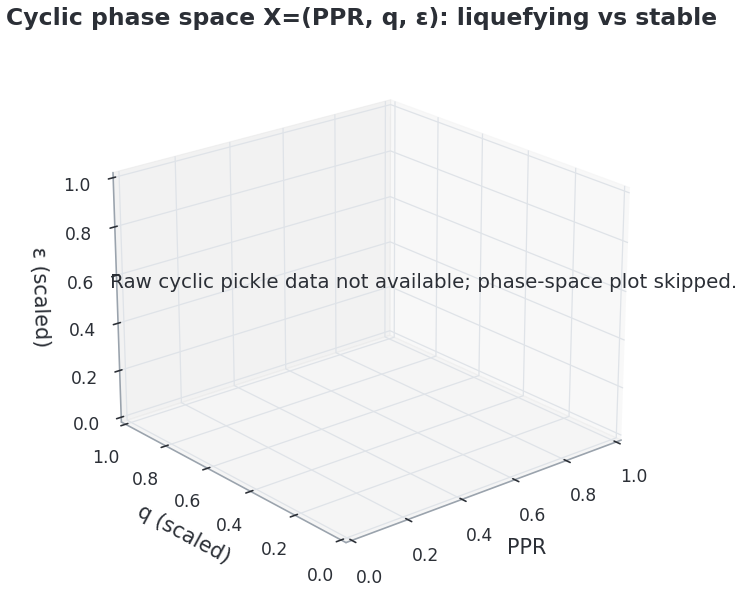

In [3]:
figw, fig = new_figure((7.2, 5.6)); ax = fig.add_subplot(111, projection="3d")
if not RAW_DATA_AVAILABLE:
    ax.text2D(0.05, 0.55, "Raw cyclic pickle data not available; phase-space plot skipped.", transform=ax.transAxes)
def add_phase(rec, color, label):
    X = build_phase_space(rec["ppr"], rec["q"], rec["eps"])
    ax.plot(X[:, 0], X[:, 1], X[:, 2], color=color, linewidth=1.3, alpha=0.9, label=label)
if liq_tests: add_phase(liq_tests[0], LIQ_C, f'liquefying {liq_tests[0]["lab"]} (N={liq_tests[0]["Nmax"]:.0f})')
if stable_tests: add_phase(stable_tests[0], STAB_C, f'stable {stable_tests[0]["lab"]} (N={stable_tests[0]["Nmax"]:.0f})')
ax.set_title("Cyclic phase space X=(PPR, q, ε): liquefying vs stable")
ax.set_xlabel("PPR"); ax.set_ylabel("q (scaled)"); ax.set_zlabel("ε (scaled)")
ax.view_init(elev=22, azim=-130)
if RAW_DATA_AVAILABLE:
    ax.legend(fontsize=8, loc="upper left")
save_figure(figw, "4_2_phase_space", SAVE_FIGS); figw

## Шаг 2. Диаграммы устойчивости одного окна

Persistent homology фазового облака: у разжижающегося отклика больше долгоживущих петель
(H1) и шире разброс компонент (H0).

In [4]:
if not RAW_DATA_AVAILABLE:
    figw, fig = new_figure((6.0, 3.2)); ax = fig.add_subplot(111)
    ax.axis("off"); ax.text(0.02, 0.55, "Raw cyclic pickle data not available; persistence-window plot skipped.", fontsize=10)
    save_figure(figw, "4_2_skip_8", SAVE_FIGS); figw
else:
    def window_dgm(rec, frac=0.5, win_cycles=5):
        X = build_phase_space(rec["ppr"], rec["q"], rec["eps"])
        ppc = max(int(round(len(rec["cycles"]) / max(rec["Nmax"], 1))), 4)
        w = ppc * win_cycles; s = int(np.clip(frac, 0, 0.9) * (len(X) - w))
        return compute_persistence(X[s:s + w], maxdim=1)
    figw, fig = new_figure((5.8, 5.4)); ax = fig.add_subplot(111); mx = 0.1
    for rec, col, nm in [(liq_tests[0], LIQ_C, "liquefying"), (stable_tests[0], STAB_C, "stable")]:
        dg = window_dgm(rec)
        for k in range(2):
            if len(dg[k]) == 0: continue
            fin = np.isfinite(dg[k][:, 1]); mx = max(mx, float(dg[k][fin, 1].max()) if fin.any() else mx)
            ax.scatter(dg[k][fin, 0], dg[k][fin, 1], s=42, marker=["o", "D"][k], color=col,
                       alpha=0.55 + 0.35 * k, edgecolors="white", linewidths=0.3, label=f"{nm} H{k}")
    ax.plot([0, mx], [0, mx], ls="--", color="#9aa3ad", linewidth=1.1)
    ax.set_title("Persistence diagrams (mid-test window): liquefying vs stable")
    ax.set_xlabel("birth"); ax.set_ylabel("death"); ax.legend(fontsize=8)
    save_figure(figw, "4_2_persistence_window", SAVE_FIGS); figw


## Шаг 3. Траектория индикатора TEWI вдоль опыта

TEWI(N) считается по скользящим окнам. У разжижающихся опытов индикатор устойчиво **выше** на
протяжении всего опыта — топология отклика «помечена» как разжижение задолго до разрушения.

In [5]:
if not RAW_DATA_AVAILABLE:
    figw, fig = new_figure((6.0, 3.2)); ax = fig.add_subplot(111)
    ax.axis("off"); ax.text(0.02, 0.55, "Raw cyclic pickle data not available; TEWI curves skipped.", fontsize=10)
    save_figure(figw, "4_2_skip_10", SAVE_FIGS); figw
else:
    def tewi_curve(rec):
        pw = topological_early_warning(rec["cycles"], rec["ppr"], rec["q"], rec["eps"],
                                       window_cycles=4, step_cycles=2)
        return pw["cycle"] / max(rec["Nmax"], 1), pw["tewi"]
    figw, fig = new_figure((7.4, 4.6)); ax = fig.add_subplot(111)
    for j, rec in enumerate(liq_tests):
        x, y = tewi_curve(rec); ax.plot(x, y, color=LIQ_C, linewidth=1.5, alpha=0.6,
                                        label="liquefying" if j == 0 else None)
    for j, rec in enumerate(stable_tests):
        x, y = tewi_curve(rec); ax.plot(x, y, color=STAB_C, linewidth=1.5, alpha=0.6,
                                        label="stable" if j == 0 else None)
    ax.set_title("Topological Early-Warning Indicator TEWI(N) along the test")
    ax.set_xlabel("normalized cycle N / N_max"); ax.set_ylabel("TEWI = total persistence H0+H1")
    ax.legend(fontsize=9)
    save_figure(figw, "4_2_tewi_curves", SAVE_FIGS); figw


## Шаг 4. TEWI как ранний предиктор разжижения

Берём TEWI, посчитанный по **раннему** участку опыта (первая четверть циклов), и проверяем,
насколько он один разделяет разжижение и стабильный отклик (ROC AUROC).

In [6]:
if not RAW_DATA_AVAILABLE:
    figw, fig = new_figure((6.0, 3.2)); ax = fig.add_subplot(111)
    ax.axis("off"); ax.text(0.02, 0.55, "Raw cyclic pickle data not available; TEWI AUROC skipped.", fontsize=10)
    save_figure(figw, "4_2_skip_12", SAVE_FIGS); figw
else:
    def early_tewi(rec, frac=0.25):
        _, y = tewi_curve(rec); q = max(int(len(y) * frac), 1)
        return float(np.mean(y[:q]))
    rows, scores, labels = [], [], []
    for rec in liq_tests:
        v = early_tewi(rec); scores.append(v); labels.append(1); rows.append(("liquefying", v))
    for rec in stable_tests:
        v = early_tewi(rec); scores.append(v); labels.append(0); rows.append(("stable", v))
    import numpy as np
    from sklearn.metrics import roc_auc_score
    auroc = roc_auc_score(labels, scores) if len(set(labels)) > 1 else float("nan")
    df = pd.DataFrame(rows, columns=["class", "early_TEWI"])
    figw, fig = new_figure((5.4, 4.6)); ax = fig.add_subplot(111)
    groups = [("liquefying", LIQ_C), ("stable", STAB_C)]
    data = [df[df["class"] == cls]["early_TEWI"].to_numpy() for cls, _ in groups]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55, showmeans=True,
                    medianprops=dict(color=INK, linewidth=1.3),
                    meanprops=dict(marker="o", markerfacecolor="white", markeredgecolor=INK, markersize=4))
    from matplotlib.colors import to_rgba
    for patch, (_, col) in zip(bp["boxes"], groups):
        patch.set_facecolor(to_rgba(col, 0.6)); patch.set_edgecolor("white")
    for i, (cls, col) in enumerate(groups, 1):
        yv = df[df["class"] == cls]["early_TEWI"].to_numpy()
        ax.scatter(np.full(len(yv), i) + np.random.uniform(-0.08, 0.08, len(yv)), yv, s=18,
                   color=col, alpha=0.8, edgecolors="white", linewidths=0.3, zorder=3)
    ax.set_xticks([1, 2]); ax.set_xticklabels([g for g, _ in groups])
    ax.set_title(f"Early-window TEWI separates liquefaction (AUROC = {auroc:.3f})")
    ax.set_ylabel("early TEWI (first 25% of cycles)")
    save_figure(figw, "4_2_tewi_auroc", SAVE_FIGS); figw.show()
    display(pd.DataFrame({"Metric": ["tests (liq/stable)", "median TEWI liquefying", "median TEWI stable",
                                     "AUROC (early TEWI → liquefaction)"],
                          "Value": [f"{len(liq_tests)}/{len(stable_tests)}",
                                    round(float(df[df['class']=='liquefying']['early_TEWI'].median()), 2),
                                    round(float(df[df['class']=='stable']['early_TEWI'].median()), 2),
                                    round(float(auroc), 3)]}))


## Итог

Устойчивая гомология фазового пространства циклического отклика `(PPR, q, ε)` даёт индикатор
**TEWI**, который у разжижающихся опытов **устойчиво выше**, чем у стабильных, причём это видно
уже по **раннему** участку нагружения (ранний предиктор). Топология отклика, таким образом,
несёт сигнал о грядущем разжижении — это и есть *Topological Early Warning Indicator*.

Что дальше для статьи **Topological Early Warning Indicators for Liquefaction**: расширить
выборку опытов, сравнить TEWI с классическими предикторами (CSR, N_liq) и проверить вклад
TEWI как дополнительного признака к DPI-Flow.